# Lesson 12: Multiple Testing, Equivalence, and Evidence Beyond Significance

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Control family-wise error or false discovery rate for multiple hypotheses
2. Distinguish confirmatory and exploratory analyses
3. Use equivalence testing to support a claim of practically negligible difference
4. Explain how estimation and sensitivity analyses improve binary decisions


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 12.1 Multiple comparisons

With $m$ independent tests at level $\alpha$, the chance of at least one false positive is
$1-(1-\alpha)^m$. Bonferroni and Holm control family-wise error; Benjamini–Hochberg controls the expected
false discovery proportion under its assumptions. Define the hypothesis family from the decision
context rather than correcting every p-value ever computed.


In [2]:
from statsmodels.stats.multitest import multipletests

anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
variables = ["age_years", "tv_news_days_per_week", "education_code", "income_code",
             "self_left_right", "clinton_left_right", "dole_left_right"]
rows = []
for variable in variables:
    clinton = anes.loc[anes["expected_vote"] == "Clinton", variable].dropna()
    dole = anes.loc[anes["expected_vote"] == "Dole", variable].dropna()
    result = stats.ttest_ind(dole, clinton, equal_var=False)
    rows.append({"variable": variable, "Dole-Clinton difference": dole.mean()-clinton.mean(),
                 "raw p": result.pvalue})
results = pd.DataFrame(rows)
for method, label in [("bonferroni", "Bonferroni"), ("holm", "Holm"), ("fdr_bh", "BH-FDR")]:
    reject, adjusted, _, _ = multipletests(results["raw p"], alpha=.05, method=method)
    results[f"{label} p"] = adjusted
    results[f"{label} reject"] = reject
results


,variable,Dole-Clinton difference,raw p,Bonferroni p,Bonferroni reject,Holm p,Holm reject,BH-FDR p,BH-FDR reject
0,age_years,1.7871,9.9508e-02,6.9655e-01,False,2.9852e-01,False,1.3931e-01,False
1,tv_news_days_per_week,-0.0785,6.5770e-01,1.0000e+00,False,1.0000e+00,False,6.5770e-01,False
2,education_code,0.2776,7.9180e-03,5.5426e-02,False,3.1672e-02,True,1.3857e-02,True
3,income_code,2.3048,1.2550e-09,8.7852e-09,True,6.2751e-09,True,2.9284e-09,True
4,self_left_right,1.7010,3.7393e-92,2.6175e-91,True,2.6175e-91,True,2.6175e-91,True
5,clinton_left_right,-1.3090,8.6813e-57,6.0769e-56,True,5.2088e-56,True,3.0385e-56,True
6,dole_left_right,0.0485,5.3228e-01,1.0000e+00,False,1.0000e+00,False,6.2099e-01,False


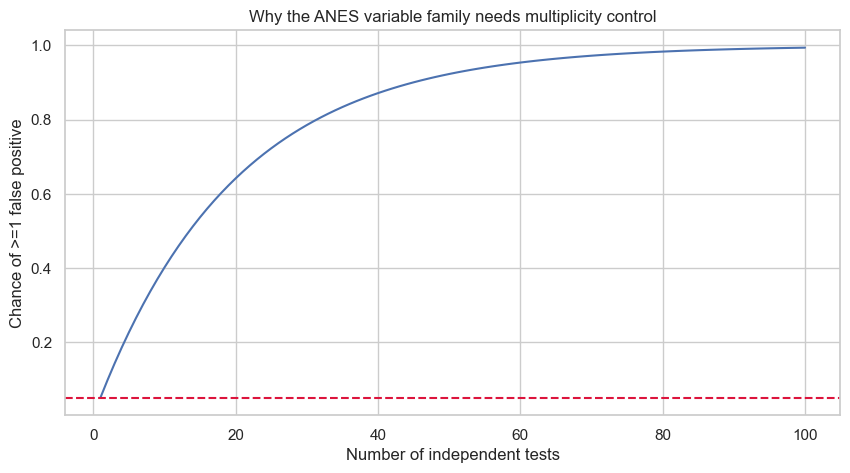

In [3]:
m = np.arange(1, 101)
fwer = 1-(1-.05)**m
fig, ax = plt.subplots()
ax.plot(m, fwer)
ax.axhline(.05, color="crimson", linestyle="--")
ax.set(xlabel="Number of independent tests", ylabel="Chance of >=1 false positive",
       title="Why the ANES variable family needs multiplicity control")
plt.show()


## 12.2 Equivalence is not non-significance

To support that an effect is small enough to be practically negligible, define equivalence bounds
$[-\Delta, +\Delta]$ before analysis. The two one-sided tests (TOST) procedure rejects effects at or
beyond both bounds. Equivalently, the $(1-2\alpha)$ confidence interval must lie wholly inside the bounds.


In [4]:
dole_age = anes.loc[anes["expected_vote"] == "Dole", "age_years"].to_numpy()
clinton_age = anes.loc[anes["expected_vote"] == "Clinton", "age_years"].to_numpy()
difference = dole_age.mean()-clinton_age.mean()
v1, v2 = dole_age.var(ddof=1), clinton_age.var(ddof=1)
n1, n2 = len(dole_age), len(clinton_age)
se = np.sqrt(v1/n1+v2/n2)
df = (v1/n1+v2/n2)**2/((v1/n1)**2/(n1-1)+(v2/n2)**2/(n2-1))
margin = 3.0  # years; a teaching equivalence threshold
t_lower = (difference-(-margin))/se
t_upper = (difference-margin)/se
p_lower = stats.t.sf(t_lower, df)
p_upper = stats.t.cdf(t_upper, df)
p_tost = max(p_lower, p_upper)
ci90 = difference + np.array([-1, 1])*stats.t.ppf(.95, df)*se
pd.Series({"age difference (Dole-Clinton)": difference, "equivalence margin": margin,
           "90% CI low": ci90[0], "90% CI high": ci90[1],
           "TOST p": p_tost, "equivalent within +/-3 years": p_tost < .05})


age difference (Dole-Clinton)    1.7871
equivalence margin                  3.0
90% CI low                       0.0026
90% CI high                      3.5715
TOST p                           0.1317
equivalent within +/-3 years      False
dtype: object

## Worked example and interpretation

### A family of seven comparisons

The first ANES analysis compares Dole and Clinton expected-vote groups on seven outcomes and adjusts the resulting p-values as one family. Income code and two political-placement measures remain clear under Bonferroni, Holm, and Benjamini–Hochberg adjustment. Education code illustrates the methods' different error targets: its raw p-value is 0.0079, Bonferroni-adjusted p is 0.0554, Holm-adjusted p is 0.0317, and BH-adjusted p is 0.0139. The methods therefore do not yield the same reject/not-reject label for this outcome. Family-wise error control and false-discovery-rate control answer different planning questions; choose the family and rule before examining the smallest p-value.

### Equivalence is a new hypothesis

A separate calculation asks whether the mean age difference is small enough to fit a **teaching** equivalence margin of ±3 years. The observed Dole-minus-Clinton difference is 1.787 years, but its 90% interval is 0.003 to 3.572 years. Because the upper limit exceeds +3, the interval is not contained within the equivalence bounds; the two-one-sided-tests p-value is 0.132. Thus neither a conventional non-significant difference test nor this equivalence test establishes equivalence. In applied work, the ±3-year margin needs subject-matter justification set in advance.

## Practice and solution

**Practice.** A conventional test gives p=.40. Can you conclude equivalence within ±2 units?

<details><summary>Solution</summary>

No. A non-significant difference test only says the data do not clearly exclude zero. Run a planned
equivalence test with bounds ±2. Equivalence is supported only if the corresponding 90% CI lies entirely
within those bounds at alpha .05.
</details>

## Key takeaways

- Multiplicity control must match the hypothesis family and error criterion.
- Exploratory findings should be labeled and independently validated.
- Equivalence testing turns "close enough" into a precise, testable claim.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
